In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from keras.src.saving import load_model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import os

In [2]:
MODEL_PATH = "output/model/v25/train_fine_tuned.keras"
TEST_DIR = "dataset/testing/"
OUTPUT_DIR = "output/testing/v25/new_test_results"
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_IMAGES_TO_DISPLAY = 5
IMAGES_PER_CLASS = 4

CLASS_NAMES = ['alcohol', 'blood', 'sexual', 'traffic_accident']
NB_CLASSES = len(CLASS_NAMES)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
print("Loading trained model...")
model = load_model(MODEL_PATH)
model.summary()

Loading trained model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,988,142 (263.17 MB)

 Trainable params: 22,983,972 (87.68 MB)

 Non-trainable params: 36,224 (141.50 KB)

 Optimizer params: 45,967,946 (175.35 MB)

In [4]:
def load_new_test_data(test_dir, image_size=IMAGE_SIZE):
    images, labels = [], []
    label_mapping = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

    for folder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, folder)
        if folder not in label_mapping or not os.path.isdir(folder_path):
            continue

        label = label_mapping[folder]
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')
    return images, labels

Loading new test data...
Running predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

📊 Classification Report (dict):
{'alcohol': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 5.0}, 'blood': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 5.0}, 'sexual': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 5.0}, 'traffic_accident': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 5.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 20.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 20.0}}


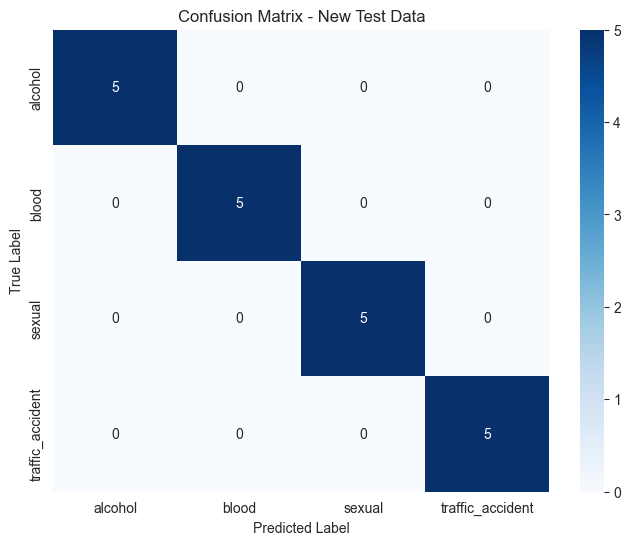

✅ Confusion matrix saved at: output/testing/v25/new_test_results/confusion_matrix.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0559 - precision: 1.0000 - recall: 1.0000
Test Accuracy: 1.0, Precision: 1.0, Recall: 1.0
Predictions saved at: output/testing/v25/new_test_results/predictions.npy
Misclassified indices: []
Misclassified images saved at: output/testing/v25/new_test_results/misclassified


In [5]:
print("Loading new test data...")
new_test_images, new_test_labels = load_new_test_data(TEST_DIR)

new_test_images_processed = new_test_images / 255.0

new_test_labels_cat = None
if new_test_labels.size > 0:
    new_test_labels_cat = np.eye(NB_CLASSES)[new_test_labels].astype('float32')

print("Running predictions...")
predictions = model.predict(new_test_images_processed)
pred_labels = np.argmax(predictions, axis=1)

if new_test_labels.size > 0:
    class_report = classification_report(new_test_labels, pred_labels, target_names=CLASS_NAMES, output_dict=True)
    print(f"\n📊 Classification Report (dict):\n{class_report}")
    with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), 'w') as f:
        f.write(str(class_report))

    cm = confusion_matrix(new_test_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - New Test Data')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
    plt.savefig(cm_path)
    plt.show()
    print(f"✅ Confusion matrix saved at: {cm_path}")

    if new_test_labels_cat is not None:
        test_loss, test_acc, test_prec, test_rec = model.evaluate(new_test_images_processed, new_test_labels_cat,
                                                                  verbose=1)
        print(f"Test Accuracy: {test_acc}, Precision: {test_prec}, Recall: {test_rec}")

np.save(os.path.join(OUTPUT_DIR, "predictions.npy"), predictions)
print(f"Predictions saved at: {os.path.join(OUTPUT_DIR, 'predictions.npy')}")

if new_test_labels.size > 0:
    misclassified_idx = np.where(pred_labels != new_test_labels)[0]
    print(f"Misclassified indices: {misclassified_idx}")

    new_test_images_scaled = (new_test_images * 255).clip(0, 255)  # Scale back to 0-255 for saving
    for idx in misclassified_idx:
        img = new_test_images_scaled[idx].astype(np.uint8)
        true_label = CLASS_NAMES[new_test_labels[idx]]
        pred_label = CLASS_NAMES[pred_labels[idx]]
        filename = f"true_{true_label}_pred_{pred_label}_{idx}.png"
        file_path = str(os.path.join(OUTPUT_DIR, "misclassified", filename))
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        success = cv2.imwrite(file_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        if not success:
            print(f"Failed to save image: {file_path}")
    print(f"Misclassified images saved at: {os.path.join(OUTPUT_DIR, 'misclassified')}")
else:
    print("No ground truth labels provided; only predictions generated.")

Displaying test images with predictions for all classes...


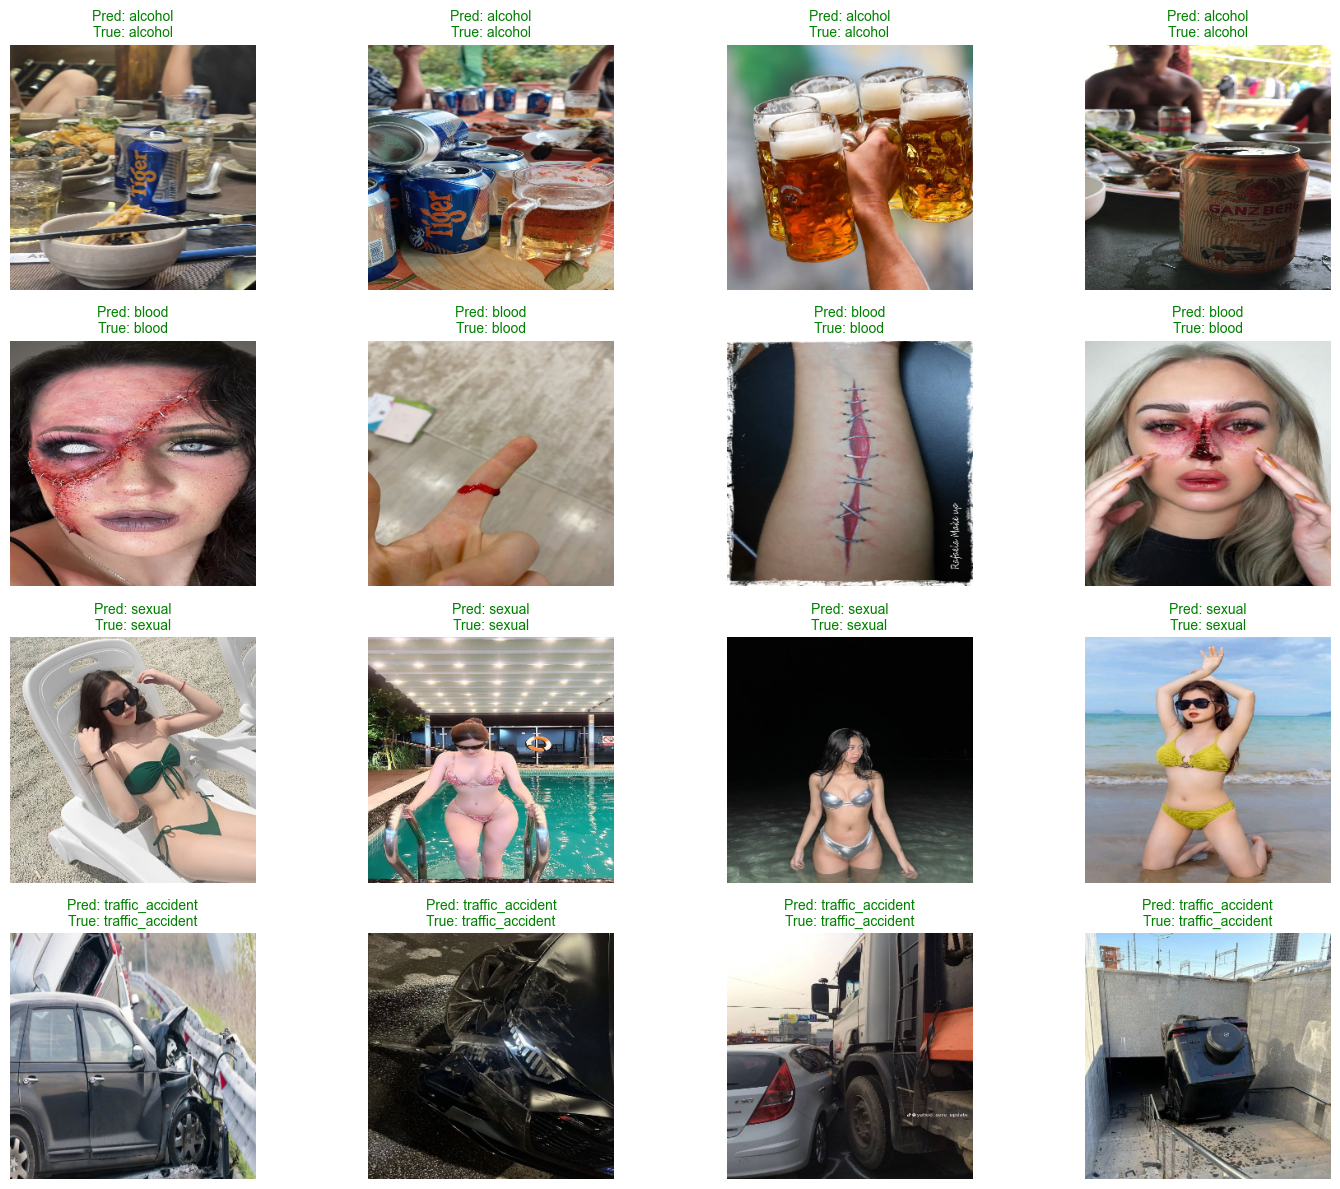


Prediction Summary:
alcohol: 5 predictions
blood: 5 predictions
sexual: 5 predictions
traffic_accident: 5 predictions


In [6]:
print("Displaying test images with predictions for all classes...")
plt.figure(figsize=(15, 12))
for class_idx in range(NB_CLASSES):
    pred_indices = np.where(pred_labels == class_idx)[0]
    num_to_show = min(IMAGES_PER_CLASS, len(pred_indices))

    for i in range(IMAGES_PER_CLASS):
        subplot_idx = class_idx * IMAGES_PER_CLASS + i + 1
        plt.subplot(NB_CLASSES, IMAGES_PER_CLASS, subplot_idx)

        if i < num_to_show:
            idx = pred_indices[i]
            img = new_test_images[idx].astype(np.uint8)
            pred_label = CLASS_NAMES[pred_labels[idx]]
            title = f"Pred: {pred_label}"
            title_color = 'black'
            if new_test_labels.size > 0:
                true_label = CLASS_NAMES[new_test_labels[idx]]
                title += f"\nTrue: {true_label}"
                title_color = 'green' if pred_label == true_label else 'red'
            plt.imshow(img)
            plt.title(title, fontsize=10, color=title_color)
        else:
            plt.text(0.5, 0.5, f"No more {CLASS_NAMES[class_idx]} predictions",
                     ha='center', va='center', fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

print("\nPrediction Summary:")
pred_counts = np.bincount(pred_labels, minlength=NB_CLASSES)
for class_idx, count in enumerate(pred_counts):
    print(f"{CLASS_NAMES[class_idx]}: {count} predictions")